In [1]:
import yfinance as ticker_data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:

asset = ticker_data.Ticker("AAPL")
current_price = asset.history(period="1d")['Close'].iloc[-1]
expirations = asset.options
# Elegimos una fecha de vencimiento cercana 
target_date = expirations[2] 
chain = asset.option_chain(target_date)

print(f"Precio actual de AAPL: ${current_price:.2f}")
print(f"Fecha de vencimiento seleccionada: {target_date}")

Precio actual de AAPL: $298.87
Fecha de vencimiento seleccionada: 2026-05-20


In [3]:
def calculate_greeks(S, K, T, r, sigma, option_type="call"):
    #funcion black sholes para  el calculo de las griegas 
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        delta = norm.cdf(d1)
        theta = (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        delta = norm.cdf(d1) - 1
        theta = (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
        
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = (S * norm.pdf(d1) * np.sqrt(T)) / 100
    return {"Delta": delta, "Gamma": gamma, "Theta": theta, "Vega": vega}

In [ ]:
# Compra Call ATM  y Vende Call OTM 
# estrategia1
strike_a = chain.calls.iloc[(chain.calls['strike'] - current_price).abs().argsort()[:1]]['strike'].values[0]
strike_b = strike_a + 10
cost_a = chain.calls[chain.calls['strike'] == strike_a]['lastPrice'].values[0]
premium_b = chain.calls[chain.calls['strike'] == strike_b]['lastPrice'].values[0]
net_cost_bull = cost_a - premium_b

In [6]:
# estrategias 2 
strike_straddle = strike_a
cost_call = cost_a
cost_put = chain.puts.iloc[(chain.puts['strike'] - strike_straddle).abs().argsort()[:1]]['lastPrice'].values[0]
total_cost_straddle = cost_call + cost_put

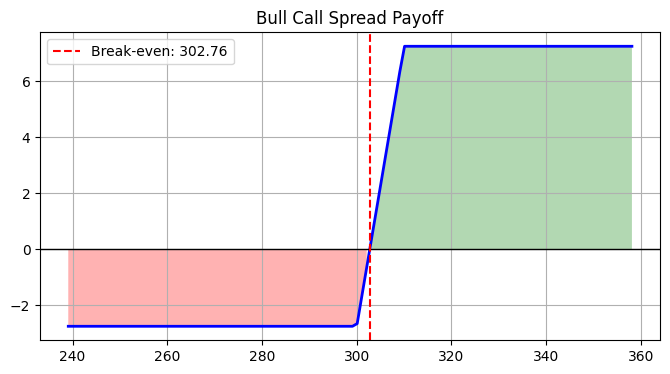

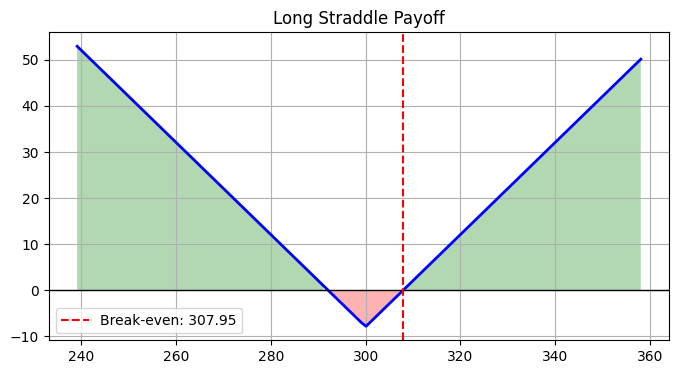

In [7]:
# Gráficas de Payoff
sT = np.arange(current_price * 0.8, current_price * 1.2, 1)

def plot_payoff(sT, payoff, title, be, max_g, max_p):
    plt.figure(figsize=(8, 4))
    plt.plot(sT, payoff, color='blue', lw=2)
    plt.axhline(0, color='black', lw=1)
    plt.axvline(be, color='red', linestyle='--', label=f'Break-even: {be:.2f}')
    plt.title(title)
    plt.fill_between(sT, payoff, 0, where=(payoff > 0), facecolor='green', alpha=0.3)
    plt.fill_between(sT, payoff, 0, where=(payoff < 0), facecolor='red', alpha=0.3)
    plt.legend()
    plt.grid(True)
    plt.show()

# Payoff Bull Call Spread
payoff_bull = np.maximum(sT - strike_a, 0) - np.maximum(sT - strike_b, 0) - net_cost_bull
plot_payoff(sT, payoff_bull, "Bull Call Spread Payoff", strike_a + net_cost_bull, (strike_b - strike_a) - net_cost_bull, -net_cost_bull)

# Payoff Long Straddle
payoff_straddle = (np.maximum(sT - strike_straddle, 0) + np.maximum(strike_straddle - sT, 0)) - total_cost_straddle
plot_payoff(sT, payoff_straddle, "Long Straddle Payoff", strike_straddle + total_cost_straddle, np.inf, -total_cost_straddle)